**Mount Google Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Load dataset**

In [2]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Invistico_Airline.csv')
df.head()

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0


**Understanding the data**

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  object 
 1   Customer Type                      129880 non-null  object 
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  object 
 4   Class                              129880 non-null  object 
 5   Flight Distance                    129880 non-null  int64  
 6   Seat comfort                       129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Food and drink                     129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Inflight wifi service              129880 non-null  int64  
 11  Inflight entertainment             1298

**checking missing value count**

In [4]:
df.isnull().sum()

,0
satisfaction,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Seat comfort,0
Departure/Arrival time convenient,0
Food and drink,0
Gate location,0


**Check the median value of the "Arrival Delay in Minutes" variable**

In [5]:
df['Arrival Delay in Minutes'].describe()

,Arrival Delay in Minutes
count,129487.000000
mean,15.091129
std,38.465650
min,0.000000
25%,0.000000
50%,0.000000
75%,13.000000
max,1584.000000


**Fill the missing values in the "Arrival delay in Minutes column" with median**

In [6]:
df['Arrival Delay in Minutes'] = (
    df['Arrival Delay in Minutes']
    .fillna(df['Arrival Delay in Minutes'].median())
)

**view columns**

In [7]:
df.columns

Index(['satisfaction', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Seat comfort', 'Departure/Arrival time convenient',
       'Food and drink', 'Gate location', 'Inflight wifi service',
       'Inflight entertainment', 'Online support', 'Ease of Online booking',
       'On-board service', 'Leg room service', 'Baggage handling',
       'Checkin service', 'Cleanliness', 'Online boarding',
       'Departure Delay in Minutes', 'Arrival Delay in Minutes'],
      dtype='object')

**Get the proportion of the category under the "satisfaction" variable**

In [8]:
df['satisfaction'].value_counts (normalize=True)*100

,proportion
satisfaction,
satisfied,54.73283
dissatisfied,45.26717


**Get a quick summary of the counts and percentage of the target variable:(satisfaction)**

In [9]:
print("Unique values:", df['satisfaction'].unique())
print("\nClass counts:")
print(df['satisfaction'].value_counts())

print("\nClass percentages:")
print(df['satisfaction'].value_counts(normalize=True) * 100)

Unique values: ['satisfied' 'dissatisfied']

Class counts:
satisfaction
satisfied       71087
dissatisfied    58793
Name: count, dtype: int64

Class percentages:
satisfaction
satisfied       54.73283
dissatisfied    45.26717
Name: proportion, dtype: float64


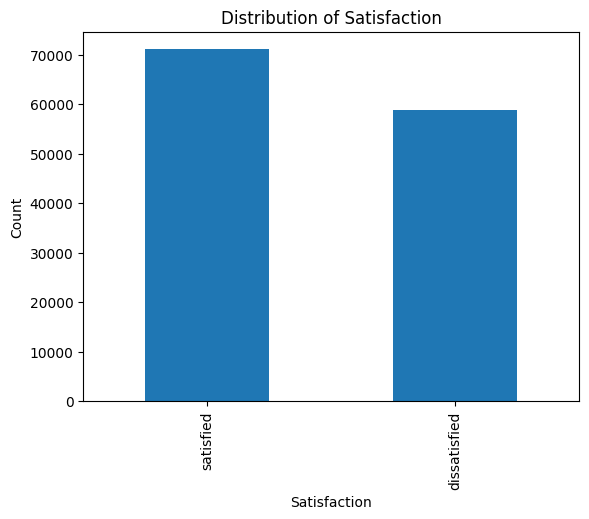

In [10]:
import matplotlib.pyplot as plt

df['satisfaction'].value_counts().plot(kind='bar')
plt.title('Distribution of Satisfaction')
plt.xlabel('Satisfaction')
plt.ylabel('Count')
plt.show()

**Interpretation**

The dataset contains 129,880 observations in total.
Satisfied customers constitute 54.73% of the dataset, while dissatisfied customers account for 45.27%.
The difference between the two classes is approximately 9.47 percentage points.
The classes are reasonably balanced, with neither class overwhelmingly dominating the dataset.
Because the class distribution is fairly even, severe class imbalance is not a concern. Therefore, standard classification algorithms such as Logistic Regression, Decision Trees, Random Forests, and KNN can be trained without immediately requiring special imbalance-handling techniques such as oversampling, undersampling, or class weighting.


**Conclusion**

The target variable (satisfaction) is a binary categorical variable with a relatively balanced distribution. Approximately 55% of passengers are satisfied and 45% are dissatisfied, indicating that the dataset is suitable for building and evaluating classification models without significant concerns about class imbalance.

**Identify categorical predictors**

In [11]:
df.select_dtypes(include='object').columns

Index(['satisfaction', 'Customer Type', 'Type of Travel', 'Class'], dtype='object')

**Separate the target variable**

In [12]:
X = df.drop('satisfaction', axis=1)
y = df['satisfaction']

**Encode the categorical predictors**

In [13]:
X_encoded = pd.get_dummies(X, drop_first=True)

**Encode the target variable(satisfaction)**

In [14]:
y = y.map({
    'dissatisfied': 0,
    'satisfied': 1
})

**Vertfy the result**

In [15]:
X_encoded.head()

,Age,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,...,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes,Customer Type_disloyal Customer,Type of Travel_Personal Travel,Class_Eco,Class_Eco Plus
0,65,265,0,0,0,2,2,4,2,3,...,3,5,3,2,0,0.0,False,True,True,False
1,47,2464,0,0,0,3,0,2,2,3,...,4,2,3,2,310,305.0,False,True,False,False
2,15,2138,0,0,0,3,2,0,2,2,...,4,4,4,2,0,0.0,False,True,True,False
3,60,623,0,0,0,3,3,4,3,1,...,1,4,1,3,0,0.0,False,True,True,False
4,70,354,0,0,0,3,4,3,4,2,...,2,4,2,5,0,0.0,False,True,True,False


In [16]:
X_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Age                                129880 non-null  int64  
 1   Flight Distance                    129880 non-null  int64  
 2   Seat comfort                       129880 non-null  int64  
 3   Departure/Arrival time convenient  129880 non-null  int64  
 4   Food and drink                     129880 non-null  int64  
 5   Gate location                      129880 non-null  int64  
 6   Inflight wifi service              129880 non-null  int64  
 7   Inflight entertainment             129880 non-null  int64  
 8   Online support                     129880 non-null  int64  
 9   Ease of Online booking             129880 non-null  int64  
 10  On-board service                   129880 non-null  int64  
 11  Leg room service                   1298

**Split data into training and testing sets**

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**Scale the predictors using StandardScalar**

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Fit the model**

In [19]:

from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

**Generate the predicted probabilities for the "satisfied" class**

In [20]:
y_pred = log_reg.predict(X_test_scaled)

y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]
#Display the first 10 predicted probabilites
pd.Series(y_prob).head(10)

,0
0,0.813647
1,0.732018
2,0.041859
3,0.974406
4,0.209819
5,0.375147
6,0.514426
7,0.102175
8,0.108982
9,0.396510


**Generate the confusion matrix**

In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 9546  2213]
 [ 2232 11985]]


**Calculate Precision and Recall**

In [22]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.84413297647556
Recall: 0.8430048533445874


**Generate a classification Report**

In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.81      0.81     11759
           1       0.84      0.84      0.84     14217

    accuracy                           0.83     25976
   macro avg       0.83      0.83      0.83     25976
weighted avg       0.83      0.83      0.83     25976



**Determine the key factors**

In [24]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_reg.coef_[0]
})

coef_df.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
7,Inflight entertainment,0.972905
2,Seat comfort,0.392582
10,On-board service,0.387346
13,Checkin service,0.355612
9,Ease of Online booking,0.334382
11,Leg room service,0.308623
15,Online boarding,0.181621
5,Gate location,0.162930
8,Online support,0.144692
12,Baggage handling,0.109271


**Model performance Interpretation**




The Logistic Regression model achieved an overall accuracy of approximately 83%, indicating strong predictive performance on unseen passenger data.

The model's precision of 84.4% means that when the model predicts a passenger is satisfied, it is correct approximately 84% of the time.

The recall of 84.3% indicates that the model successfully identifies approximately 84% of all genuinely satisfied passengers.

The classification report shows balanced performance across both classes, with F1-scores of 0.81 for dissatisfied passengers and 0.84 for satisfied passengers. This suggests that the model is not heavily biased toward either class and provides reliable predictions of customer satisfaction.

The model achieved a precision of 84.4%, meaning that when a passenger is predicted to be satisfied, the prediction is correct 84.4% of the time. The recall of 84.3% indicates that the model successfully identifies 84.3% of truly satisfied passengers. Since precision and recall are both high and balanced, the model demonstrates a good trade-off between minimizing false positives and false negatives


**Interpret  Model coefficient to Identify Key factors of satisfaction**


In Logistic Regression:

Positive coefficients increase the likelihood of a passenger being Satisfied.
Negative coefficients decrease the likelihood of a passenger being Satisfied.
The larger the coefficient (in absolute value), the stronger its influence.

**Strongest Positive Drivers of satisfacton**

| Feature                | Coefficient |
| ---------------------- | ----------: |
| Inflight entertainment |       0.973 |
| Seat comfort           |       0.393 |
| On-board service       |       0.387 |
| Checkin service        |       0.356 |
| Ease of Online booking |       0.334 |
| Leg room service       |       0.309 |


**Interpretation**

Inflight entertainment emerged as the strongest positive predictor of customer satisfaction. This suggests that passengers who rate the airline's entertainment services highly are substantially more likely to be satisfied.

Other important positive drivers include:

Seat comfort
On-board service
Check-in service
Ease of online booking
Leg room service

These findings indicate that both the in-flight experience and the customer journey before boarding play a major role in determining satisfaction levels.

**Strongest Negative Drivers of Satisfaction**

| Feature                           | Coefficient |
| --------------------------------- | ----------: |
| Customer Type_disloyal Customer   |      -0.725 |
| Class_Eco                         |      -0.355 |
| Type of Travel_Personal Travel    |      -0.350 |
| Departure/Arrival time convenient |      -0.329 |
| Food and drink                    |      -0.296 |
| Arrival Delay in Minutes          |      -0.262 |


**Interpettion**

The strongest negative predictor was being a disloyal customer, indicating that non-loyal customers are significantly less likely to be satisfied.

Other factors associated with lower satisfaction include:

Traveling in Economy Class
Traveling for personal rather than business purposes
Longer arrival delays
Lower ratings for food and beverage services
Lower ratings for departure and arrival time convenience

The negative coefficient for Arrival Delay in Minutes confirms that delays adversely affect customer satisfaction.

**Business Recommendation Based on Model Insights**


1. **Continue Investing in Inflight Entertainment**

"Inflight entertainment exhibited the strongest positive relationship with satisfaction and should therefore be prioritized for service improvement initiatives." The airline should continue improving entertainment offerings by:

Expanding movie and television selections
Improving screen quality and reliability
Providing personalized entertainment options

This is likely to generate the greatest improvement in overall customer satisfaction.

2. **Enhance Passenger Comfort**

Seat comfort and leg room service were among the most influential positive factors.

The airline should:

Upgrade seating quality where feasible
Improve seat ergonomics
Offer additional legroom options

Improving passenger comfort can directly increase satisfaction levels.

3. **Improve Service Quality Across Customer Touchpoints**

The model highlights the importance of:


*    On-board service
*    Check-in service
*    Online booking


Management should continue investing in staff training and digital service improvements to ensure a seamless customer experience from booking through arrival.

4. **Reduce Flight Delays**

Arrival delays negatively affect customer satisfaction.

The airline should:

* Improve operational efficiency
* Optimize scheduling
* Enhance delay communication procedures

Even when delays are unavoidable, proactive communication can help mitigate dissatisfaction.

5. **Focus on Economy-Class Passengers**

Passengers traveling in Economy Class were less likely to be satisfied.

The airline should consider:

* Improving economy cabin comfort
* Enhancing meal quality
* Providing additional value-added services

Since economy passengers constitute a large portion of airline customers, even modest improvements could have a significant impact.

6. **Strengthen Customer Loyalty Programs**

Disloyal customers were substantially less likely to be satisfied.

The airline should:

* Expand loyalty and rewards programs
* Offer personalized promotions
* Encourage repeat bookings through targeted incentives

Improving customer retention may increase both satisfaction and long-term profitability.

**Overall Conclusion**

The Logistic Regression model achieved approximately 83% accuracy, with 84.4% precision and 84.3% recall, demonstrating strong predictive performance. The most important drivers of satisfaction were inflight entertainment, seat comfort, on-board service, and check-in service, while disloyal customer status, economy-class travel, personal travel, and arrival delays were associated with lower satisfaction. These insights provide clear opportunities for the airline to improve customer experience and increase overall passenger satisfaction.

**Limitations**


1. **Model assumptions**

Logistic Regression assumes a linear relationship between predictors and the log-odds of satisfaction, which may not fully capture complex customer behaviors.

2. **Limited feature set**

The model only uses variables available in the dataset. Other factors influencing satisfaction, such as ticket price, weather disruptions, or airport conditions, were not included.

3. **Historical data**

The model was trained on historical observations and may not fully reflect future changes in customer preferences.

4. **Correlation vs causation**

The model identifies associations with satisfaction but does not prove that a variable directly causes satisfaction.

**Next Steps for Deployment**



1. **Monitor model performance regularly**

Retrain the model periodically as new passenger data becomes available.

2. **Integrate into customer experience systems**

Use predicted satisfaction probabilities to identify at-risk passengers and trigger proactive service recovery actions.

3. **Compare with advanced models**

Evaluate models such as Random Forests, Gradient Boosting, or XGBoost to determine whether predictive performance can be improved.

4. **Collect additional customer data**

Incorporate variables such as fare price, loyalty status details, and operational disruptions to enhance prediction accuracy.